<a href="https://colab.research.google.com/github/shorkelleyss-dot/Musiccomputing2026/blob/main/labassignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display
import scipy.signal as sg
# import audio files
!git clone https://github.com/jcdevaney/musicComputing2026.git

Cloning into 'musicComputing2026'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 136 (delta 59), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 21.22 MiB | 13.71 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [3]:
def plotTimeFreq(sig,sr,title,winSize,specType,fig):

    # copy from filters.ipynb
    # Adjust the x-axis to represent time
    time=np.arange(0,sig.shape[0])/sr

    # Scale the y-axis to represent amplitude from -1 to 1
    excursion=max(abs(sig))
    sigNew = sig / excursion

    # Label the x and y axes with variables
    xlabel = 'Time (seconds)'
    ylabel = 'Amplitude'

    # Create a new figure (using the figure number passed in as an argument)
    plt.figure(fig)

    # Create the first subplot
    plt.subplot(2,1,1)

    # Plot the time-domain representation of the inputted audio signal
    plt.plot(time,sigNew)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Create the second subplot
    plt.subplot(2,1,2)

    # Plot the frequency-domain representatio of the inputted audio signal
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig,n_fft=winSize)), ref=np.max)
    librosa.display.specshow(spec, y_axis=specType)
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.show



In [6]:
def filterSignal(sig,sr,freq,filterFreq,filtType,order,winsize,specType,fig):

    # Inputs
    #   - signal to filter (sig)
    #   - sampling rate of the signal (sr)
    #   - filter frequency/frequencies (freq)
    #   - filter type (filtType)
    #   - order of the filter (order)
    #   - window size for the FFT (winSize)
    #   - type of spectrogram, log or linear (specType)
    #   - figure number (fig)
    sig , sr = librosa.load('musicComputing2026/audioFiles/avm.wav')
    title='original'
    winSize = 1024
    specType = 'log'
    fig = 1
    plotTimeFreq(sig,sr,title,winSize,specType,fig)
    IPython.display.Audio(data=sig, rate=sr)

    # use an if/elif/else statement with ‘or’ tests to set up the parameters for the different   type of filter based on the code in filters.ipynb and or.ipynb, specifically
	  #   if the filter type is ‘low’ or ‘high’
		#       filterFreq = freq / (sr / 2)
	  #   if the filter type if ‘bandpass’ or ‘bandstop’
		#       filterFreq = [freq[0] / (sr / 2), freq[1] / (sr / 2)]
    def functionWithOptions(text):
       if filtType == "low" or text == "high":
           filterFreq = freq / (sr / 2)
           print("Greetings")
       elif text == "bandpass" or text == "bandstop":
           filterFreq = [freq[0] / (sr / 2), freq[1] / (sr / 2)]
           print("See you later")
       else:
        print(text)

    # create a filter using using sg.butter()
    b, a = sg.butter(order, filterFreq, filtType)

    # run the created filter on the inputting signal using sg.filtfilt()
    sig_fil1a = sg.filtfilt(b, a, sig)

    # plot the filtered signal with plotTimeFreq(), use filtType for title
    plotTimeFreq(sig_fil1a,sr,filtType,winSize,specType,fig)
    IPython.display.Audio(data=sig_fil1a, rate=sr)

    # return the filtered signal
    return sig_fil1a

In [9]:
def allFilters(sig,sr,freq,width,order,winSize,specType):


    # Inputs
    #   - signal to filter (sig)
    #   - sampling rate of the signal (sr)
    #   - filter frequency/frequencies (freq)
    #   - filter type (filtType)
    #   - order of the filter (order)
    #   - window size for the FFT (winSize)
    #   - type of spectrogram, log or linear (specType)
    #   - figure number (fig)
    sig , sr = librosa.load('musicComputing2026/audioFiles/avm.wav')
    title='original'
    winSize = 1024
    specType = 'log'
    fig = 1
    plotTimeFreq(sig,sr,title,winSize,specType,fig)
    IPython.display.Audio(data=sig, rate=sr)

    # call filterSignal() to run a low-pass filter on the inputting signal using
    # the inputting filter frequency and filter order
    # set fig equal to 1
    filterSignal(sig,sr,freq,filterFreq,filtType,order,winSize,specType,fig)

    order = 1
    filterFreq = 400 / (sr / 2) # convert frequency to between 0 and 1
    filtType = 'low'
    fig = 1

    b, a = sg.butter(order, filterFreq, filtType)


    sig_lp = sg.filtfilt(b, a, sig)

    plotTimeFreq(sig_lp,sr,filtType,winSize,specType,fig)
    IPython.display.Audio(data=sig_lp, rate=sr)
    # call filterSignal() to run a high-pass filter on the inputting signal
    # using the inputting filter frequency and filter order
    # set fig equal to 2
    filterSignal(sig,sr,freq,filterFreq,filtType,order,winSize,specType,fig)

    order = 4
    filterFreq = 800 / (sr / 2) # convert frequency to between 0 and 1
    filtType = 'high'
    fig = 2

    b, a = sg.butter(order, filterFreq, filtType)
    sig_hp = sg.filtfilt(b, a, sig)

    plotTimeFreq(sig_hp,sr,filtType,winSize,specType,fig)
    IPython.display.Audio(data=sig_hp, rate=sr)
    #call filterSignal() to run a band-pass filter on the inputting signal using
    # the inputting filter frequency and filter order – filter frequency will be
    # calculated using the inputted width parameter like this:
    #                   [freq-width,freq+width]
    # set fig equal to 3
    filterSignal(sig,sr,freq,filterFreq,filtType,order,winSize,specType,fig)

    order = 4
    filterFreq = [800 / (sr / 2), 1600 / (sr / 2)] # convert frequency to between 0 and 1
    filtType = 'bandpass'
    fig = 1

    b, a = sg.butter(order, filterFreq, filtType)
    sig_bp = sg.filtfilt(b, a, sig)

    plotTimeFreq(sig_bp,sr,filtType,winSize,specType,fig)
    IPython.display.Audio(data=sig_bp, rate=sr)

    # call filterSignal() to run a band-stop filter on the inputting signal using
    # the inputting filter frequency and filter order – filter frequency will be
    # calculated using the inputted width parameter like this:
    #                   [freq-width,freq+width]
    # set fig equal to 4
    order = 4
    filterFreq = [800 / (sr / 2), 1600 / (sr / 2)] # convert frequency to between 0 and 1
    filtType = 'bandstop'
    fig = 4

    b, a = sg.butter(order, filterFreq, filtType)
    sig_bs = sg.filtfilt(b, a, sig)

    plotTimeFreq(sig_bs,sr,filtType,winSize,specType,fig)
    IPython.display.Audio(data=sig_bs, rate=sr)

    # return the output of the low-pass, high-pass, bandpass, and bandstop
    # filtered signals
    return sig_lp, sig_hp, sig_bp, sig_bs

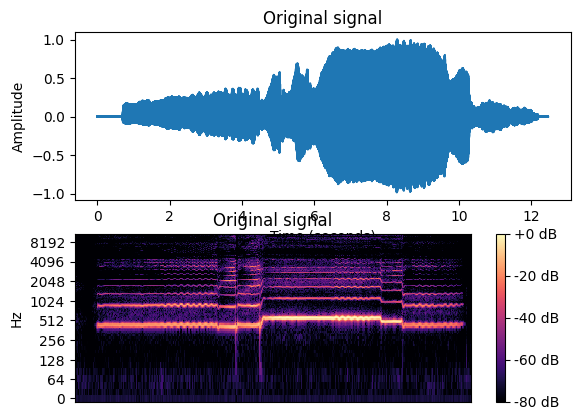

In [12]:
  sig , sr = librosa.load('musicComputing2026/audioFiles/avm.wav')
  winSize = 1024
  specType = 'log'
  fig = 1

  # Plot original signal with plotTimeFreq()
  plotTimeFreq(sig,sr,'Original signal',winSize,specType,fig)
  IPython.display.Audio(data=sig, rate=sr)
  # Play original signal with IPython.display.Audio()

In [15]:
freq = 600
width = 200
order = 4

# call allFilters() and save the output as sig_lp, sig_hp, sig_bp, sig_bs


In [ ]:
# play the low-pass version of the signal with IPython.display.Audio()


In [ ]:
# play the high-pass version of the signal with IPython.display.Audio()


In [ ]:
# play the band-pass version of the signal with IPython.display.Audio()


In [ ]:
# play the band-stop version of the signal with IPython.display.Audio()
